In [37]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_ollama import ChatOllama
from langchain.messages import RemoveMessage#this function is used to make permanent deletion from the state 


In [38]:
from langgraph.graph.message import MessagesState

In [39]:
model= ChatOllama(model="llama3.1:8b")

In [40]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [41]:
builder=StateGraph(MessagesState)
builder.add_node(chat,'chat')
builder.add_node(delete_old_messages,'delete_old_messages')


In [42]:
builder.add_edge(START,'chat')
builder.add_edge('chat','delete_old_messages')
builder.add_edge('delete_old_messages',END)

In [43]:
graph = builder.compile(checkpointer=InMemorySaver())

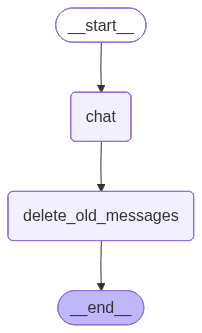

In [44]:
graph

In [45]:
config={"configurable":{'thread_id':'thread_1'}}

In [46]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Osama BIN"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='46d12feb-2f9c-4976-ab3e-07a2ad1c9ae4'),
  AIMessage(content='**LangChain: A Library for Building Conversational AI**\n======================================================\n\nLangChain is an open-source library for building conversational artificial intelligence (AI) applications. It provides a set of tools and APIs to create, train, and deploy conversational models that can engage in natural-sounding conversations.\n\n**Key Features**\n\n*   **Conversational Models**: LangChain supports the creation and training of various types of conversational models, including language models, dialog management systems, and knowledge graphs.\n*   **Knowledge Graphs**: The library enables the construction and querying of knowledge graphs, which are essential for building informative and context-aware conversations.\n*   **Dialogue Management**: LangChain provides APIs for managing dialogue flows

In [54]:
snap=graph.get_state(config)
total_conversation=snap.values['messages']

In [55]:
print("Stored messages after cleanup",len(total_conversation))

Stored messages after cleanup 8
